# Laboratorium 3: regresja liniowa prosta

Notebook zawiera:
1. odpowiedzi do zadania o regresji na zbiorze `tips`,
2. własny przykład regresji prostej na innym zbiorze danych.

## Zadanie 1: `tip ~ total_bill`

Najpierw uruchamiam przykład z materiałów, a następnie zapisuję odpowiedzi do pytań z instrukcji.

In [4]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

tips = sns.load_dataset("tips")
y = tips["tip"]
X = sm.add_constant(tips["total_bill"])
model_tips = sm.OLS(y, X).fit()

print(model_tips.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           6.69e-34
Time:                        01:58:59   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

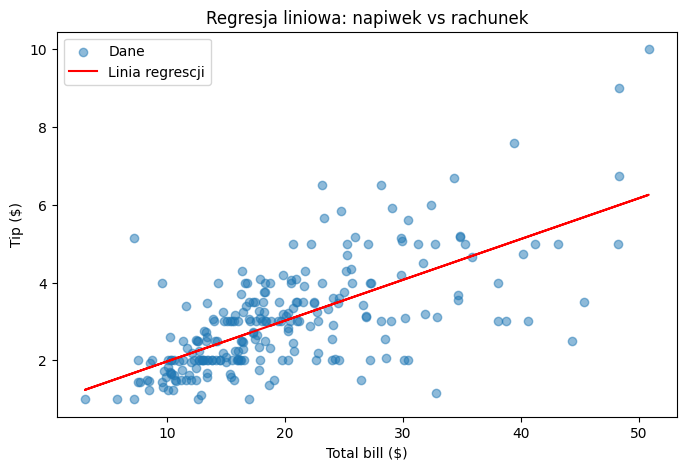

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(tips["total_bill"], tips["tip"], alpha=0.5, label="Dane")
plt.plot(tips["total_bill"], model_tips.predict(X), color="red", label="Linia regrescji")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)")
plt.title("Regresja liniowa: napiwek vs rachunek")
plt.legend()
plt.show()

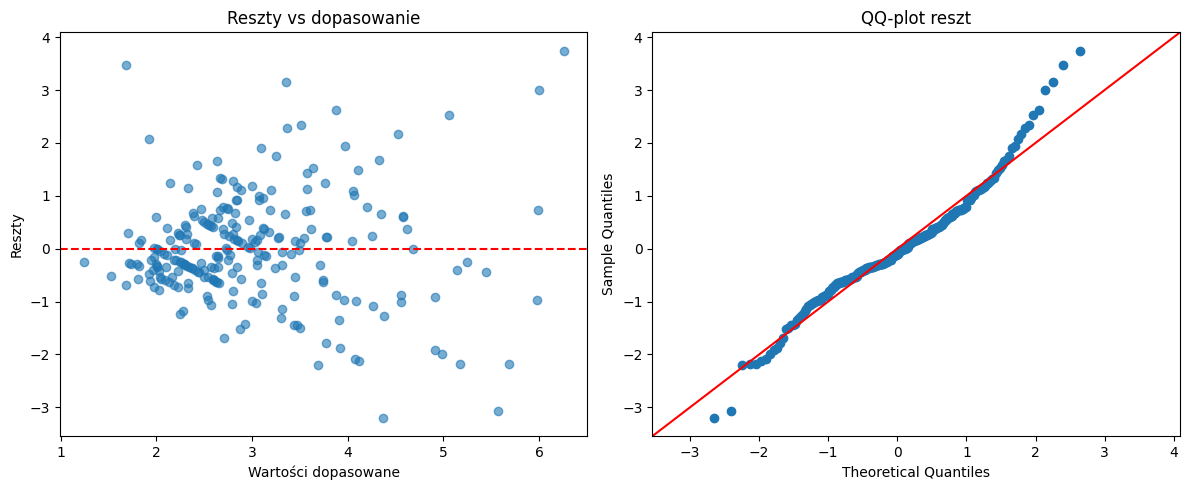

In [6]:
residuals = model_tips.resid
fitted = model_tips.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(fitted, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Wartości dopasowane")
axes[0].set_ylabel("Reszty")
axes[0].set_title("Reszty vs dopasowanie")

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("QQ-plot reszt")

plt.tight_layout()
plt.show()

### Odpowiedzi do zadania 1

1. Interpretacja modelu

1.1. Współczynnik β1 mówi, o ile średnio zmienia się napiwek, gdy rachunek rośnie o 1 dolar. W tym modelu oznacza to przeciętny przyrost napiwku wraz ze wzrostem rachunku.

1.2. Wyraz wolny β0 to przewidywany napiwek przy rachunku równym 0. Jest to punkt przecięcia prostej z osią Y.

1.3. W tym przypadku wyraz wolny ma słaby sens praktyczny, bo rachunek równy 0 nie opisuje rzeczywistej sytuacji restauracyjnej.

2. Statystyki dopasowania

2.1. R² pokazuje, jaka część zmienności napiwków jest wyjaśniana przez rachunek. Im większe R², tym lepsze dopasowanie modelu.

2.2. Wysoka wartość p-value przy współczynniku oznacza, że nie ma mocnych podstaw do uznania go za istotnie różny od zera. W praktyce taki predyktor może nie wnosić ważnej informacji.

2.3. Istotny test F oznacza, że cały model jako całość jest statystycznie użyteczny i przynajmniej jedna zmienna objaśniająca ma istotny wpływ na wynik.

3. Reszty i diagnostyka

3.1. Normalność reszt można sprawdzić wykresem QQ-plot lub testem Shapiro-Wilka.

3.2. Kształt lejka na wykresie reszt sugeruje heteroskedastyczność, czyli zmienną wariancję błędów.

3.3. Duże odejście QQ-plot od linii 45° oznacza brak normalności reszt, co osłabia założenia klasycznej regresji liniowej.

4. Rozszerzenie modelu

4.1. Po dodaniu zmiennej `size` model miałby postać `tip ~ total_bill + size`. Byłaby to już regresja wieloraka.

4.2. Zmienne kategoryczne, takie jak `day` lub `time`, można włączyć przez kodowanie zero-jedynkowe, czyli zmienne sztuczne.

4.3. Dodanie zmiennych nie zawsze poprawia model. Może zwiększyć złożoność bez realnej poprawy jakości albo prowadzić do przeuczenia.

5. Praktyczne aspekty

5.1. Taki model może służyć do prognozowania napiwków, planowania przychodów i oceny zależności między rachunkiem a napiwkiem.

5.2. Ograniczeniem jest to, że model uwzględnia tylko jeden predyktor. Pomija np. jakość obsługi, porę dnia, dzień tygodnia czy liczbę osób przy stoliku.

5.3. Na napiwek mogą wpływać m.in. jakość obsługi, liczba osób, pora dnia, dzień tygodnia, promocje, lokalizacja stolika i zwyczaje klientów.

## Zadanie 2: własny przykład regresji prostej

Jako drugi przykład wybrałem zbiór `mpg` z Seaborn. Sprawdzam zależność między zużyciem paliwa `mpg` a mocą silnika `horsepower`. To nadal regresja prosta, bo używam jednej zmiennej objaśniającej.

In [7]:
mpg = sns.load_dataset("mpg")
mpg_clean = mpg[["mpg", "horsepower"]].dropna()

y_mpg = mpg_clean["mpg"]
X_mpg = sm.add_constant(mpg_clean["horsepower"])
model_mpg = sm.OLS(y_mpg, X_mpg).fit()

print(model_mpg.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 22 Apr 2026   Prob (F-statistic):           7.03e-81
Time:                        01:59:09   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

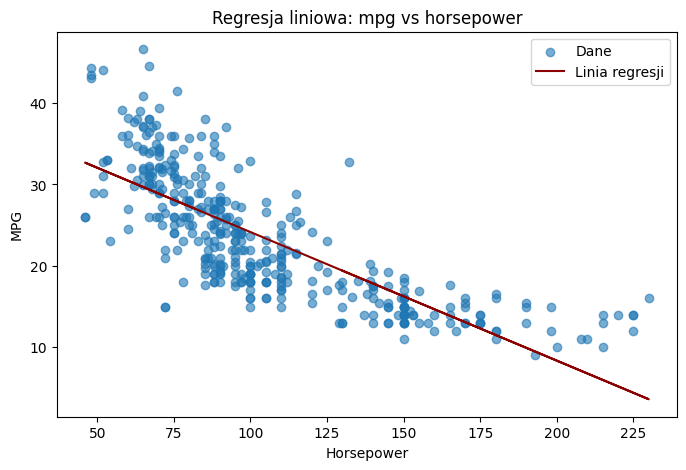

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(mpg_clean["horsepower"], mpg_clean["mpg"], alpha=0.6, label="Dane")
plt.plot(mpg_clean["horsepower"], model_mpg.predict(X_mpg), color="darkred", label="Linia regresji")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Regresja liniowa: mpg vs horsepower")
plt.legend()
plt.show()

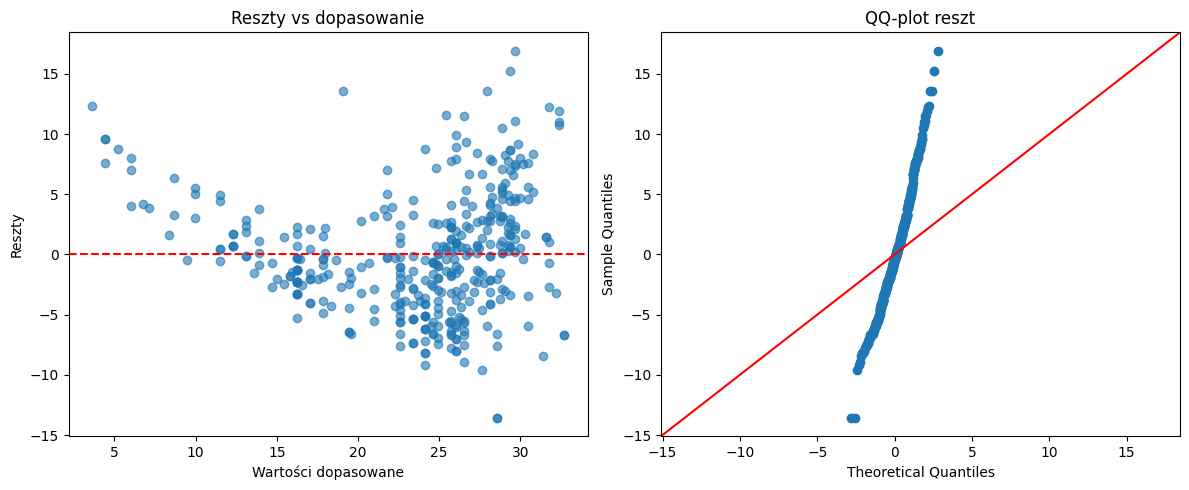

In [9]:
residuals_mpg = model_mpg.resid
fitted_mpg = model_mpg.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(fitted_mpg, residuals_mpg, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Wartości dopasowane")
axes[0].set_ylabel("Reszty")
axes[0].set_title("Reszty vs dopasowanie")

sm.qqplot(residuals_mpg, line="45", ax=axes[1])
axes[1].set_title("QQ-plot reszt")

plt.tight_layout()
plt.show()

### Krótka interpretacja przykładu

W tym modelu współczynnik przy `horsepower` zwykle jest ujemny, co oznacza, że większa moc silnika wiąże się ze spadkiem `mpg`, czyli gorszą ekonomiką spalania. To sensowny przykład regresji prostej, bo pokazuje czytelną zależność jednej zmiennej objaśniającej od jednej zmiennej zależnej.

Gdyby trzeba było rozwinąć model, można by dodać np. masę auta, liczbę cylindrów albo rok produkcji, ale wtedy byłaby to już regresja wieloraka.